# Simulating Juliette

In [116]:
import pandas as pd
import xarray as xr
import numpy as np
from opendrift.models.openberg import OpenBerg
from opendrift.readers.reader_netCDF_CF_generic import Reader    
from datetime import datetime,timedelta, timezone
from utils2 import calc_iceberg_size

In [156]:
#Read and subset Tracker data
df = pd.read_csv('../input/Osker-X2.csv', sep=';')
df['time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
ds = xr.Dataset.from_dataframe(df)
ds_daily = ds.groupby("time.date").first()
ds_3day = ds_daily.isel(date=slice(0, None, 3))
#idx = np.arange(ds_3day.lat.size) #ADAPT LATER
idx=np.array([0,1,])
print(idx,dt)

[0 1] <xarray.DataArray 'time' (date: 4)> Size: 32B
array(['2025-09-24T00:00:31.000000', '2025-09-27T00:00:31.000000',
       '2025-09-30T00:00:31.000000', '2025-10-03T00:00:31.000000'],
      dtype='datetime64[us]')
Coordinates:
  * date     (date) object 32B 2025-09-24 2025-09-27 2025-09-30 2025-10-03


In [160]:
#def initial conditions
idxx=0
iceberg = {
            #'lat':None,'lon':None,'time':None,
           'length':200,'width':85, 
            'number':int(2*4),'radius':500}
iceberg = calc_iceberg_size(iceberg)

o=OpenBerg(loglevel=10,logfile='../results/out.log')
o.add_readers_from_list(['cmems_mod_glo_phy_anfc_0.083deg_PT1H-m','cmems_mod_arc_phy_my_topaz4_P1D-m',]) 
r = Reader('../input/era5_juliette.nc',standard_name_mapping={'u10':'x_wind','v10':'y_wind'},name='ERA5-Reader')
o.add_reader(r)
#o.seed_elements(**iceberg)
for idxx in idx: 
    o.seed_elements(lon=ds_3day.lon[idxx],lat=ds_3day.lat[idxx],time=ds_3day.time[idxx].astype("datetime64"),**iceberg)
    print(idxx,ds_3day.time[idxx])
oi = o.run(duration=timedelta(days=3),outfile='../results/out.nc')

oi

0 <xarray.DataArray 'time' ()> Size: 8B
array('2025-09-24T00:00:31.000000', dtype='datetime64[us]')
Coordinates:
    date     object 8B 2025-09-24
1 <xarray.DataArray 'time' ()> Size: 8B
array('2025-09-27T00:00:31.000000', dtype='datetime64[us]')
Coordinates:
    date     object 8B 2025-09-27


Fetching catalogue 1: 100%|██████████| 2/2 [00:00<00:00,  3.62it/s]
INFO - 2026-05-07T14:18:12Z - Selected dataset version: "202406"
INFO - 2026-05-07T14:18:12Z - Selected dataset part: "default"
Fetching catalogue 1: 100%|██████████| 2/2 [00:00<00:00, 36.18it/s]
INFO - 2026-05-07T14:18:13Z - Selected dataset version: "202506"
INFO - 2026-05-07T14:18:13Z - Selected dataset part: "default"


<xarray.Dataset> Size: 99kB
Dimensions:                                   (trajectory: 8, time: 73)
Coordinates:
  * trajectory                                (trajectory) int32 32B 0 1 ... 6 7
  * time                                      (time) datetime64[ns] 584B 2025...
Data variables: (12/39)
    status                                    (trajectory, time) float64 5kB ...
    moving                                    (trajectory, time) float64 5kB ...
    age_seconds                               (trajectory, time) float32 2kB ...
    origin_marker                             (trajectory, time) float64 5kB ...
    lon                                       (trajectory, time) float32 2kB ...
    lat                                       (trajectory, time) float32 2kB ...
    ...                                        ...
    sea_water_salinity                        (trajectory, time) float32 2kB ...
    sea_ice_area_fraction                     (trajectory, time) float32 2kB ...
    sea_ice_thickness                         (trajectory, time) float32 2kB ...
    sea_ice_x_velocity                        (trajectory, time) float32 2kB ...
    sea_ice_y_velocity                        (trajectory, time) float32 2kB ...
    land_binary_mask                          (trajectory, time) float32 2kB ...
Attributes: (12/147)
    Conventions:                                                           CF...
    standard_name_vocabulary:                                              CF...
    featureType:                                                           tr...
    title:                                                                 Op...
    summary:                                                               Ou...
    keywords:                                                              tr...
    ...                                                                    ...
    geospatial_lon_units:                                                  de...
    geospatial_lon_resolution:                                             point
    runtime:                                                               0:...
    geospatial_vertical_min:                                               0.0
    geospatial_vertical_max:                                               0.0
    geospatial_vertical_positive:                                          up

In [162]:
idx

array([0, 1])

AttributeError: 'numpy.datetime64' object has no attribute 'strftime'

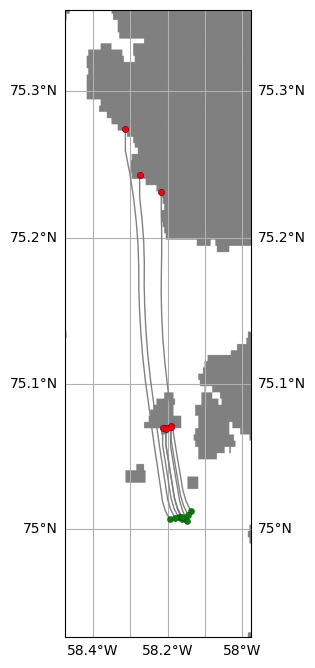

In [164]:
o.plot(fast=True)

In [ ]:
#test 2-3 sizes, by sat L=200m, W=85, D%??

#coeffcients: 
